In [1]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.stats import entropy
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import random as rng
from sklearn.metrics import mutual_info_score
import seaborn as sns
from sklearn import linear_model
from sklearn.neural_network import MLPRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import mutual_info_classif
from scipy.interpolate import RegularGridInterpolator
from scipy import constants as constants

#defaultclock.dt = 0.01 * ms
defaultclock.dt = 0.01 * ms
prefs.codegen.target = 'numpy'

INFO       Cache size for target 'cython': 3109397211 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the 'C:\Users\Tansu Celikel\.cython\brian_extensions' directory. [brian2]


# Model Setup and utils

In [2]:
def DefineFavAngle_nat_oriented(forward_low, forward_high, backward_low, backward_high, nb_neuron):
    forward = [rng.randrange(forward_low, forward_high, 10) for i in range(0, int(nb_neuron/2))]
    backward = [rng.randrange(backward_low, backward_high, 10) for i in range(0, int(nb_neuron/2))]
    fav_angle = np.concatenate((np.asarray(forward), np.asarray(backward)))
    return fav_angle

In [3]:
def CreateDirection(value, duration):
    direction = np.ones(duration) * value
    return TimedArray(direction, dt=defaultclock.dt)

In [4]:
def CreateAmplitude(value, duration):
    amplitude = np.ones(duration) * value
    return TimedArray(amplitude, dt=defaultclock.dt)

In [5]:
def CreateAmplitudeOnOff(amplitude, duration):
    amplitudeOnOff = np.zeros(duration)
    amplitudeOnOff[np.where(amplitude>0)] = 1
    return TimedArray(amplitudeOnOff, dt=defaultclock.dt)

In [6]:
'''
Function CreateRampAndHoldStim 
    Create a stimulus composed of a constant direction and a ramp and hold amplitude of whisker deflection with a 
    timestep of 1-ms
    
    Input :
        -startTime : The time at which the ON ramp start (beginning of the increase in amplitude)
        -endTime   : The time at which the OFF ramp ends (ending of the decreases in amplitude)
        -maxamp    : The value of amplitude at which the ramp shall culminate and be maintained during the 
                     hold phase
        -minamp    : The minimal amplitude of the stimulus (most likely 0, which means resting)
        -angle     : The direction of the whisker deflection
        -rampTime  : The duration of the ramp phases
        -duration  : The duration of the entire simtulus
        
    Output :
        -direction : A timed array containing the angle of the stimulus for each timestep
        -amp       : A timed array containing the amplitude of the stimulus for each timestep
        -amp_on    : A timed array containing 1 if the amplitude is above 0 or 0 otherwise for each timestep
'''
def CreateRampAndHoldStimAmpOnOff(startTime, endTime, maxamp, minamp, angle, rampTime, duration):
    direction = [angle]
    amp = [minamp]
    amp_on = []
    for i in range(1, duration):
        #To rearrange amp_on = amp>threshold
        if i >= startTime and i < endTime:
            amp_on.append(1)
        else:
            amp_on.append(0)
        direction.append(angle)
        if i >= startTime and i < (endTime - rampTime):
            if amp[i-1] < maxamp :
                amp.append(amp[i-1] + maxamp/rampTime)
            else :
                amp.append(maxamp)
        else:
            if i >= (endTime - rampTime) and amp[i-1] > minamp:
                amp.append(amp[i-1] - maxamp/rampTime)
            else:
                amp.append(minamp)
    direction = TimedArray(direction, dt=1*ms)
    amp_on = TimedArray(amp_on, dt=1*ms)
    amp = TimedArray(amp, dt=1*ms)
    return direction, amp, amp_on

In [7]:
'''
Function CreateRampAndHoldStim 
    Create a stimulus composed of a constant direction and a ramp and hold amplitude of whisker deflection with a 
    timestep of 1-ms
    
    Input :
        -startTime : The time at which the ON ramp start (beginning of the increase in amplitude)
        -endTime   : The time at which the OFF ramp ends (ending of the decreases in amplitude)
        -maxamp    : The value of amplitude at which the ramp shall culminate and be maintained during the 
                     hold phase
        -minamp    : The minimal amplitude of the stimulus (most likely 0, which means resting)
        -angle     : The direction of the whisker deflection
        -rampTime  : The duration of the ramp phases
        -duration  : The duration of the entire simtulus
        
    Output :
        -direction : A timed array containing the angle of the stimulus for each timestep
        -amp       : A timed array containing the amplitude of the stimulus for each timestep
        -amp_on    : A timed array containing 1 if the amplitude is above 0 or 0 otherwise for each timestep
'''
def CreateRampAndHoldStimAmpOnOff(startTime, endTime, maxamp, minamp, angle, rampTime, duration, dt):
    # Initialize arrays
    direction = np.full(duration, angle)
    amp_on = np.zeros(duration)
    amp = np.full(duration, minamp)

    # Set amp_on based on time range
    amp_on[startTime:endTime] = 1

    # Calculate amp values
    for i in range(startTime, endTime):
        if i < (endTime - rampTime):
            amp[i] = min(maxamp, amp[i-1] + maxamp/rampTime)
        else:
            amp[i] = max(minamp, amp[i-1] - maxamp/rampTime)

    # Create TimedArrays
    direction = TimedArray(direction, dt=dt)
    amp_on = TimedArray(amp_on, dt=dt)
    amp = TimedArray(amp, dt=dt)

    return direction, amp, amp_on


In [8]:
def compute_spontaneous_activity(spike_times, duration):
    spontaneous_activity = np.zeros((duration, 1))
    spike_times = np.round(spike_times/ms)
    for i in range(duration):
        spontaneous_activity[i] = sum(spike_times==i)
    return spontaneous_activity

In [9]:
def summarize_data(spike_SA1, spike_SA2, spike_RA, spike_TG, spike_PSV, stimulus, stimulus_name, duration, title):
    data1 = compute_spontaneous_activity(spike_SA1.t, duration)
    data2 = compute_spontaneous_activity(spike_SA2.t, duration)
    data3 = compute_spontaneous_activity(spike_RA.t, duration)
    data4 = compute_spontaneous_activity(spike_TG.t, duration)
    data5 = compute_spontaneous_activity(spike_PSV.t, duration)
    
    plot_activity(data1, data2, data3, data4, data5, stimulus, stimulus_name, title)

In [10]:
def plot_activity(data1, data2, data3, data4, data5, stimulus, stimulus_name, title):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs[0, 0].plot(data1/28)
    axs[0, 0].set_ylabel('p_spikes')
    axs[0, 0].set_title('SA1 activity')
    
    axs[0, 1].plot(data2/28)
    axs[0, 1].set_title('SA2 activity')
    
    axs[1, 0].plot(data3/70)
    axs[1, 0].set_ylabel('p_spikes')
    axs[1, 0].set_title('TG activity')
    
    axs[1, 1].plot(data4/70)
    axs[1, 1].set_title('BS activity')

    axs[2, 0].plot(data5/70)
    axs[2, 0].set_title('TC activity')
    
    axs[2, 1].plot(stimulus)
    axs[2, 1].set_ylabel(stimulus_name)
    axs[2, 1].set_xlabel('duration')
    axs[2, 1].set_title('Stimulus')

    fig.suptitle(title)
    plt.show()

In [11]:
def compute_nb_spike_per_neuron(spike, nb_neuron):
    nb_spike=np.zeros(nb_neuron)
    for i in np.unique(spike.i):
        nb_spike[i] = sum(spike.i == i)
    return nb_spike


In [12]:
def compute_nb_spike_per_neuron_time_window(spike, nb_neuron, start_time, end_time):
    nb_spike=np.zeros(nb_neuron)
    for i in np.unique(spike.i):
        nb_spike[i] = sum(np.where(np.asarray(spike.i) == i, 1, 0) * np.where(np.asarray(spike.t/ms)>start_time, 1, 0) * np.where(np.asarray(spike.t/ms) <=end_time, 1, 0))
    return nb_spike

In [13]:
def decoding_pipeline_training(X, y):
    clf = linear_model.PoissonRegressor()
    mlp = MLPRegressor()
    gnb = GaussianNB()

    clf.fit(X, y)
    #print('Linear decoder score : ' + str(clf.score(X, y)))
    mlp.fit(X, y)
    #print('MLP decoder score : ' + str(mlp.score(X, y)))
    gnb.fit(X, y)
    #print('Bayesian decoder score : ' + str(gnb.score(X, y)))

    return clf, mlp, gnb

In [34]:
tg = '''
dISRA/dt = (a_null * (v  - El_tg) - ISRA)/tau_SRA_null : amp
Il = Gl_bar * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA + Iapp)/Cm : volt

Iapp : amp
'''

SA1 = '''
Iapp = I(t) * (amplitudeOnOff(t)) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_SA1/dt = (a_SA1 * (v  - El_tg) - ISRA_SA1)/tau_SRA1 : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_SA1 + Iapp + randn() * 100 * pA)/Cm : volt

fav_direction : 1
'''

RA = '''
Iapp = I(t) * (amplitudeOnOff(t)) * log(1 + ((amplitude(t) - amplitude(t-(1 * dt))) ** 2)) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_RA/dt = (a_RA * (v  - El_tg) - ISRA_RA)/tau_RA : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_RA + Iapp)/Cm : volt

fav_direction : 1
'''

SA2 = '''
Iapp = I(t) * (amplitude(t)/90) * ((1 + cos((direction(t) - fav_direction) * (pi/180)))/2) : amp
dISRA_SA2/dt = (a_SA2 * (v  - El_tg) - ISRA_SA2)/tau_SRA2 : amp
Il = Gl_tg * (El_tg - v + delta_th * exp((v - Vth_tg)/delta_th)) : amp
dv/dt = (Il - ISRA_SA2 + Iapp + randn() * 100 * pA)/Cm : volt

fav_direction : 1
'''

TH_eq = '''
dv/dt = (Iapp - INa - IK - IT - Ih - ILeak - IKleak)/Cm : volt

INa = gNa * m**3 * h * (v - ENa) : amp/meter**2
IK = gK * n**4 * (v - EK) : amp/meter**2
ILeak = gleak * (v - Eleak) : amp/meter**2
IKleak = gKleak * (v - EKleak) : amp/meter**2
IT = gCa * mT_inf**2 * hT * (v - ECa) : amp/meter**2
Ih = gh * (o1 + 2*(1 - c1 - o1)) * (v - Eh) : amp/meter**2

dm/dt = alpha_m * (1 - m) - beta_m * m : 1
dh/dt = alpha_h * (1 - h) - beta_h * h : 1
dn/dt = alpha_n * (1 - n) - beta_n * n : 1
dhT/dt = (hT_inf - hT) / tau_hT : 1

ECa = ((GasConst * 309.15*kelvin) / (2 * FaradConst)) * log(2 / CaBuffer) : volt
CaBufferTemp = ((-10 * IT/(amp/meter**2)) / (2 * FaradConst / (coulomb/mole))) : 1
dCaBuffer/dt = (int(CaBufferTemp > 0) * CaBufferTemp + (0.00024-CaBuffer)/5 ) / ms : 1 

do1/dt = (0.001 * (1 - c1 - o1) - 0.001 * ( (1-p0) / 0.01)) * o1 / ms : 1
dp0/dt = (0.0004 *  (1 - p0) - 0.0004 * ((CaBuffer / 0.002)**4) * p0) / ms : 1
dc1/dt = beta * o1 - alpha * c1 : 1

alpha_m = ((0.32 * (13 - (v/mV + 35))) / (exp((13 - (v/mV + 35))/4) - 1)) / ms : Hz
beta_m = ((0.28 * ((v/mV + 35) - 40)) / (exp(((v/mV + 35) - 40)/5) - 1)) / ms : Hz
alpha_h = (0.128 * exp((17 - v/mV - 35)/18)) / ms : Hz
beta_h = (4 / (1 + exp((40 - v/mV - 35)/5))) / ms : Hz

alpha_n = ((0.032 * (15 - (v/mV + 25))) / (exp((15 - (v/mV + 25))/5) - 1)) / ms : Hz
beta_n = (0.5 * exp((10 - (v/mV + 25)) / 40)) / ms : Hz

alpha = h_inf / tau_s : Hz
beta = (1 - h_inf) / tau_s : Hz

mT_inf = 1 / (1 + exp((-((v/mV + 2) + 57)) / 6.2)) : 1
hT_inf = 1 / (1 + exp(((v/mV + 2) + 81)/4)) : 1
tau_hT = (( 30.8 + (211.4 + exp(((v/mV+2) + 113.2)/5))/(1+exp(((v/mV + 2)+84)/3.2))) / 3.73) * ms : second

h_inf =  1 / (1 + exp( (v/mV + 75)/5.5 )) : 1
tau_s = (20 + 1000 / (exp( (v/mV + 71.5)/14.2 ) + exp( (-(v/mV + 89))/11.6))) * ms: second
    
Cm = 1*uF/cm**2 : farad/meter**2
Iapp : amp/meter**2
        '''

In [35]:
def model_mechano(fav_direction_SA1, fav_direction_SA2, fav_direction_RA):

    Eleak = -70*mV 
    VPM_neuron_num = 70

    El= -50 * mV

    SA1_pop = NeuronGroup(24, SA1, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA1 = ISRA_SA1 + b_SA1''', dt = 1*ms)
    SA2_pop = NeuronGroup(10, SA2, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_SA2 = ISRA_SA2 + b_SA2''', dt = 1*ms)
    RA_pop = NeuronGroup(36, RA, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg 
                          ISRA_RA = ISRA_RA''', dt = 1*ms)
    TG_pop = NeuronGroup(70, tg, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg''', dt = 1*ms)
    BS_pop = NeuronGroup(70, tg, method = 'euler', threshold='v > Vth_tg',
                          reset = '''v = Vreset_tg''', dt = 1*ms)
    
    TC_cells = NeuronGroup(VPM_neuron_num, TH_eq, threshold = 'v > spike_detect', refractory = 'v > spike_detect', method='rk4')
    TC_cells.v = -70*mV  # Resting potential

    TC_cells.m = 0 + np.finfo(float).eps
    TC_cells.h = 0 + np.finfo(float).eps
    TC_cells.n = 0 + np.finfo(float).eps
    TC_cells.hT = 0 + np.finfo(float).eps
    TC_cells.CaBuffer = 0 + np.finfo(float).eps
    TC_cells.o1 = 0 + np.finfo(float).eps
    TC_cells.c1 = 0 + np.finfo(float).eps
    TC_cells.p0 = 0 + np.finfo(float).eps


    S1 = Synapses(SA1_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 0.01 * ms)
    S1.connect(condition='i==j')
    S2 = Synapses(SA2_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 0.01 * ms)
    S2.connect(condition='i+24==j')
    S3 = Synapses(RA_pop, TG_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 0.01 * ms)
    S3.connect(condition='i+36==j')
    S4 = Synapses(TG_pop, BS_pop, model = 'w : volt', on_pre='v += 25*mV', dt = 0.01 * ms)
    S4.connect(condition='i==j')
    S5 = Synapses(BS_pop, BS_pop ,model = 'w : volt', on_pre='v -= 50*mV', dt = 0.01 * ms)
    S5.connect(p=0.01)
    S6 = Synapses(BS_pop, TC_cells,model = 'w : volt', on_pre='v += 25*mV')
    S6.connect(condition='i==j')
    
    
    trace = StateMonitor(TC_cells, True, record = True)
    spike_SA1 = SpikeMonitor(SA1_pop)
    spike_SA2 = SpikeMonitor(SA2_pop)
    spike_RA = SpikeMonitor(RA_pop)
    spike_TG = SpikeMonitor(TG_pop)
    spike_BS = SpikeMonitor(BS_pop)
    spike_TC = SpikeMonitor(TC_cells)
    
    SA1_pop.v = El
    SA1_pop.fav_direction = fav_direction_SA1
    
    SA2_pop.v = El
    SA2_pop.fav_direction = fav_direction_SA2
    
    RA_pop.v = El
    RA_pop.fav_direction = fav_direction_RA
    
    TG_pop.v = El
    BS_pop.v = El
    
    model = Network()
    
    model.add(SA1_pop)
    model.add(SA2_pop)
    model.add(RA_pop)
    model.add(TG_pop)
    model.add(BS_pop)
    model.add(TC_cells)

    model.add(S1)
    model.add(S2)
    model.add(S3)
    model.add(S4)
    model.add(S5)
    model.add(S6)
    
    model.add(spike_SA1)
    model.add(spike_SA2)
    model.add(spike_RA)
    model.add(spike_TG)
    model.add(spike_BS)
    model.add(spike_TC)
    model.add(trace)

    return model, trace, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC

In [36]:
def run_model(direction, amplitude, amplitudeOnOff, I, model, duration):
    
    ENa = 50*mV 
    EK = -100*mV 
    spike_detect = 0 * mV
    
    Eh = -43*mV 
    Eleak = -70*mV
    EKleak = -100*mV

    m = 0 + np.finfo(float).eps
    h = 0 + np.finfo(float).eps
    n = 0 + np.finfo(float).eps
    hT = 0 + np.finfo(float).eps
    CaBuffer = 0 + np.finfo(float).eps
    o1 = 0 + np.finfo(float).eps
    c1 = 0 + np.finfo(float).eps
    p0 = 0 + np.finfo(float).eps

    gNa = 90*msiemens/cm**2
    gK = 20*msiemens/cm**2
    gCa = 2*msiemens/cm**2
    gh = 0.01*msiemens/cm**2
    gleak = 0.01*msiemens/cm**2
    gKleak = 0.0172*msiemens/cm**2

    FaradConst = constants.physical_constants['Faraday constant'][0] * coulomb/mole
    GasConst = constants.gas_constant * joule / (kelvin * mole)

    a_SA1 = 20.23676859919913 * nS
    b_SA1= 69.64621029919265 * pA
    tau_SRA1 = 44.089198785866415 * 100 * ms
    a_SA2 = 46.111299501668576 * nS
    b_SA2 = 3.213718541167184 * pA
    tau_SRA2 = 1882.0521336373106 * 100 * ms
    a_RA = 59.10061355050058 * nS
    b_RA = 86.53424254697113 * pA
    tau_RA = 1890.103325320332 * 100 * ms
    
    a_null = 0 * nS
    b_null = 0 * pA
    tau_SRA_null = 2000 * ms


    Gl_bar = G_bar = 1/(633 * 10 ** 6) * siemens

    El_tg = -50 * mV
    El = -70 * mV
    Gl_tg = 10 * nS
    Cm = 0.1 * nF
    Vth = -50 * mV
    Vth_tg = -30 * mV

    Vreset_tg = -45 * mV
    Vreset = -65 * mV
    delta_th = 5 * mV
    
    model.run(duration * ms)

In [37]:
fav_angles_SA1 = DefineFavAngle_nat_oriented(45, 135, 225, 315, 24) #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_SA2 = DefineFavAngle_nat_oriented(45, 135, 225, 315, 10)  #define_favorite_angles_gauss(90, 270, 45, 76)
fav_angles_RA =  DefineFavAngle_nat_oriented(45, 135, 225, 315, 36) #define_favorite_angles_gauss(90, 270, 45, 50)

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 5., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 

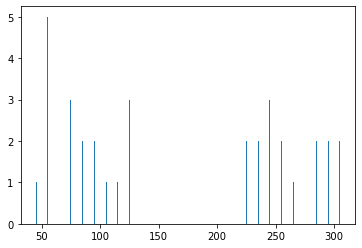

In [38]:
plt.hist(fav_angles_RA, bins=360)

In [39]:
duration = 400
direction =  CreateDirection(90, duration)
amplitude =  CreateAmplitude(90, duration)
amplitudeOnOff = CreateAmplitudeOnOff(amplitude.values, duration)

WARNING    'h' is an internal variable of group 'neurongroup_17', but also exists in the run namespace with the value 2.220446049250313e-16. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'hT' is an internal variable of group 'neurongroup_17', but also exists in the run namespace with the value 2.220446049250313e-16. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'o1' is an internal variable of group 'neurongroup_17', but also exists in the run namespace with the value 2.220446049250313e-16. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'p0' is an internal variable of group 'neurongroup_17', but also exists in the run namespace with the value 2.220446049250313e-16. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'CaBuffer' is an internal variable of group 'neurongro

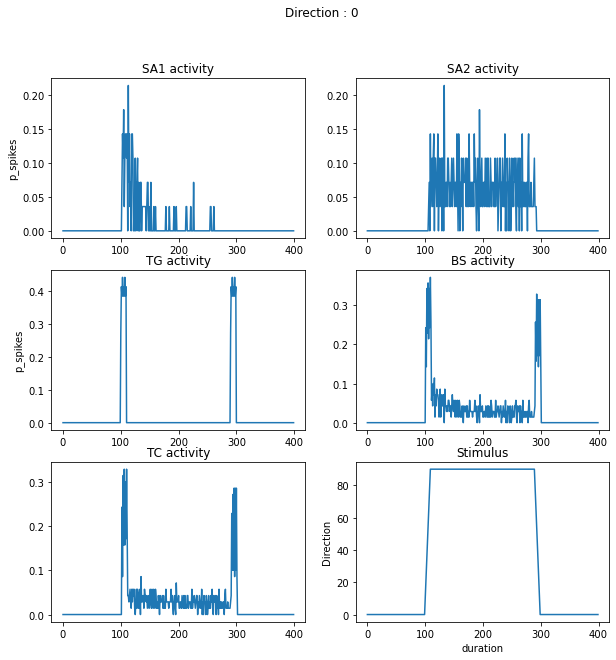

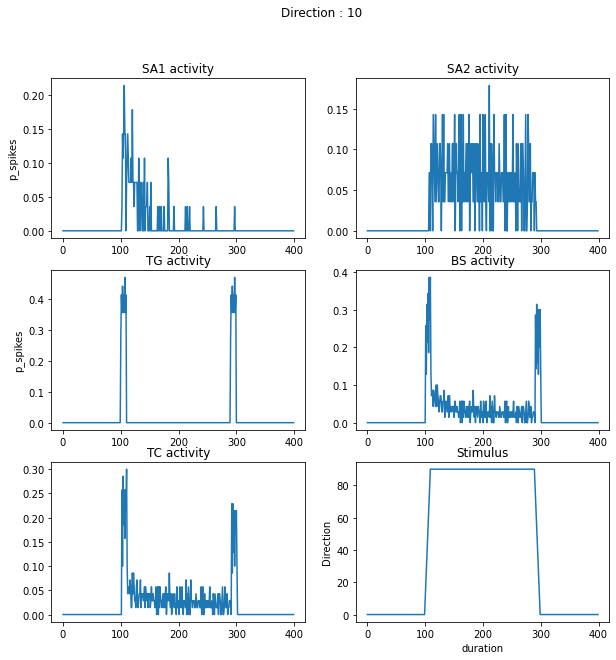

In [40]:
SA1_act = []
SA2_act = []
RA_act = []
TG_act = []
BS_act = []
TC_act = []
folder = './activity_per_direction/'
for d in range(0, 20, 10):
    model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC = model_mechano(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
    I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
    direction, amplitude, amplitudeOnOff = CreateRampAndHoldStimAmpOnOff(100, 300, 90, 0, d, 10, 400, 1 * ms)
    run_model(direction, amplitude, amplitudeOnOff, I, model, duration)
    summarize_data(spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, amplitude.values, 'Direction', duration, 'Direction : ' + str(d))
    numpy.savetxt('direction_' + str(d) +'_time', np.asarray(spike_BS.t), delimiter=',')
    numpy.savetxt('direction_' + str(d) +'_id', np.asarray(spike_BS.i), delimiter=',')
    #SA1_act.append(compute_spontaneous_activity(spike_SA1.t, duration))
    #SA2_act.append(compute_spontaneous_activity(spike_SA2.t, duration))
    #RA_act.append(compute_spontaneous_activity(spike_RA.t, duration))
    #TG_act.append(compute_spontaneous_activity(spike_TG.t, duration))
    #BS_act.append(compute_spontaneous_activity(spike_BS.t, duration))
    #TC_act.append(compute_spontaneous_activity(spike_TC.t, duration))

In [48]:
spike_SA1.t

<spikemonitor_6.t: array([102., 103., 103., 103., 103., 104., 104., 104., 105., 105., 105.,
       105., 106., 106., 106., 106., 106., 106., 107., 107., 107., 107.,
       108., 108., 108., 108., 110., 110., 111., 111., 111., 112., 112.,
       112., 112., 113., 113., 113., 114., 114., 115., 115., 116., 116.,
       117., 117., 118., 118., 118., 119., 119., 120., 120., 120., 120.,
       120., 121., 121., 122., 122., 123., 124., 124., 125., 125., 126.,
       126., 127., 127., 128., 128., 131., 131., 131., 132., 132., 134.,
       134., 135., 135., 136., 139., 139., 141., 141., 141., 143., 144.,
       145., 146., 146., 150., 152., 152., 164., 167., 170., 175., 182.,
       182., 182., 183., 183., 192., 212., 215., 219., 243., 265., 297.]) * msecond>

In [241]:
direction, amplitude, amplitudeOnOff = CreateRampAndHoldStimAmpOnOff(100, 900, 90, 0, 90, 10, 1000, dt=1*ms)

Text(0.5, 1.0, 'Direction')

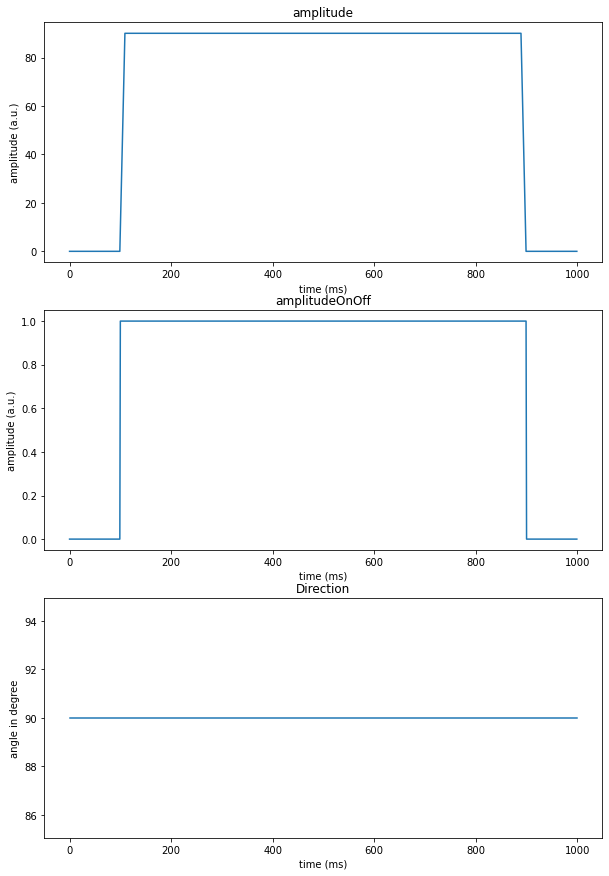

In [242]:
fig, axes = plt.subplots(3,1, figsize=(10, 15))
axes[0].plot(amplitude.values)
axes[0].set_xlabel('time (ms)')
axes[0].set_ylabel('amplitude (a.u.)')
axes[0].set_title('amplitude')

axes[1].plot(amplitudeOnOff.values)
axes[1].set_xlabel('time (ms)')
axes[1].set_ylabel('amplitude (a.u.)')
axes[1].set_title('amplitudeOnOff')

axes[2].plot(direction.values)
axes[2].set_xlabel('time (ms)')
axes[2].set_ylabel('angle in degree')
axes[2].set_title('Direction')

In [ ]:
plt.plot(direction.values)
plt.xlabel('time (ms)')
plt.ylabel('amplitude (a.u.)')

In [197]:
len(range(0,360, 10))

36

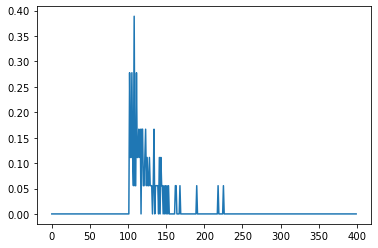

In [198]:
plt.plot(np.sum(SA1_act, axis=0)/(36 * 28))

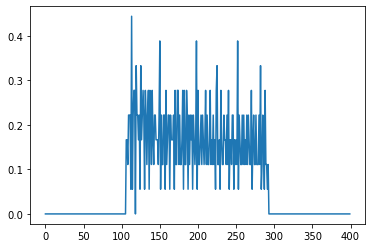

In [199]:
plt.plot(np.sum(SA2_act, axis=0)/(36 * 28))

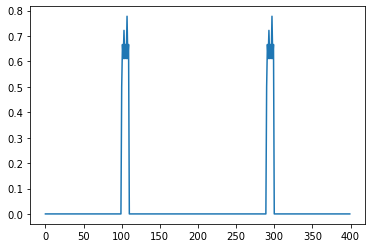

In [200]:
plt.plot(np.sum(RA_act, axis=0)/(36 * 14))

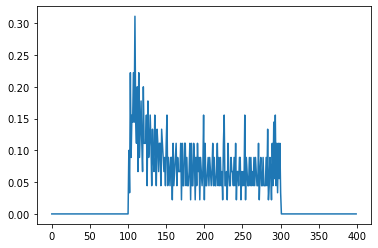

In [201]:
plt.plot(np.sum(TG_act, axis=0)/(36 * 70))

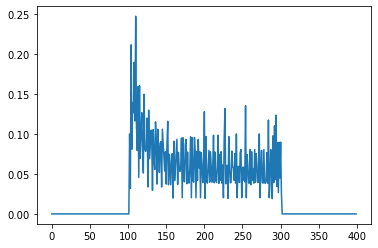

In [202]:
plt.plot(np.sum(BS_act, axis=0)/(36 * 70))

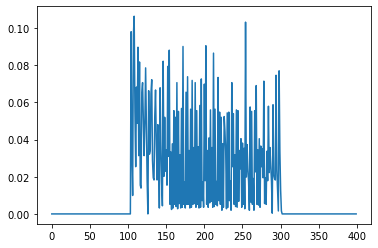

In [203]:
plt.plot(np.sum(np.asarray(TC_act), axis=0)/(36 * 70))

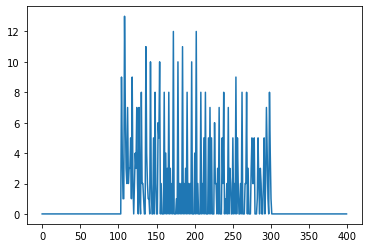

In [204]:
plt.plot(compute_spontaneous_activity(spike_TC.t, duration))

In [21]:
model, statemon, spike_SA1, spike_SA2, spike_RA, spike_TG, spike_BS, spike_TC = model_mechano(fav_angles_SA1, fav_angles_SA2, fav_angles_RA)
I = TimedArray(np.ones(duration) * 900 * pA, dt=defaultclock.dt)
direction, amplitude, amplitudeOnOff = CreateRampAndHoldStimAmpOnOff(100, 300, 90, 0, 90, 10, 400)
run_model(direction, amplitude, amplitudeOnOff, I, model, duration)

WARNING    Note that the synaptic pathway 'synapses_11_pre' will run on the clock of the group 'neurongroup_10' using a dt of 1. ms. Either the Synapses object 'synapses_11' or the target 'neurongroup_11' (or both) are using a different dt. This might lead to unexpected results. In particular, all delays will be rounded to multiples of 1. ms. If in doubt, try to ensure that 'neurongroup_10', 'synapses_11', and 'neurongroup_11' use the same dt. [brian2.synapses.synapses.synapses_dt_mismatch]


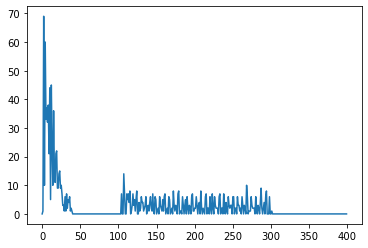

In [22]:
plt.plot(compute_spontaneous_activity(spike_TC.t, duration))

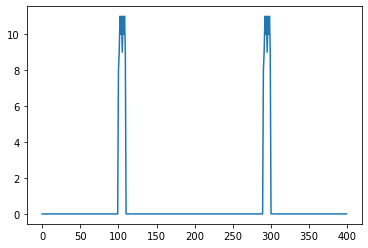

In [219]:
plt.plot(RA_act[3])